## Assignment-1
| Name          | Roll Number |
|---------------|-------------|
| Anushk Kumar  | 2023115     |
| Arhan Jain    | 2023118     |


Importing all the required Libraries
```bash
numpy
sklearn
```

In [67]:
import sklearn as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import random
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
from sklearn.datasets import fetch_kddcup99
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from scipy.sparse import csc_matrix

## Question 1

In [46]:
class Hash_Table:
    def __init__(self, m = 1, hashing = "default", p = 524287):
        if (hashing == "default"):
            self.A = [[] for i in range(m)]
            self.p = p
            self.m = m
            self.a = random.randrange(1, p)
        else:
            self.hash_dict = {}
            self.m = m
            for i in range(m):
                self.hash_dict[i] = []
        
    def universal_hash_function(self, X):
        h_x = ((self.a * X) % self.p) % self.m
        self.insert_uni(h_x, X)
        return h_x
    
    def insert_uni(self, hash, X):
        self.A[hash].append(X)
        
    def hash_md5_string(string):
        has = hashlib.sha256(string.encode('utf-8')).hexdigest()
        dec_from_hex = {'0':0, '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7':7, '8':8, '9':9, 'a':10, 'b':11, 'c':12, 'd':13, 'e':14, 'f':15}
        to_dec = dec_from_hex[has[-4]]*(16**3) + dec_from_hex[has[-3]]*(16**2) + dec_from_hex[has[-2]]*(16) + dec_from_hex[has[-1]]
        return to_dec

    def random_hash_function(self, X):
        h_x = int(self.m * random.random())
        self.insert_rand(h_x, X)
        return h_x
    
    def insert_rand(self, hash, X):
        if hash in self.hash_dict.keys():
            self.hash_dict[hash].append(X)
        else:
            self.hash_dict[hash] = [X]

In [47]:
hash_table = Hash_Table(m=10)
hash_table.universal_hash_function(123456)
hash_table.universal_hash_function(654321)
print("Universal Hash Table:")
print(hash_table.A)

Universal Hash Table:
[[], [], [], [123456], [], [], [], [654321], [], []]


In [48]:
# Q1 b)
df = pd.DataFrame(columns = ['String', 'HashVal'])
words = []
with open('words.txt', 'r') as f:
    words = f.readlines()

word_hash = []
has_vals = []

for w in words:
    temp = w
    if (w[-1] == '\n'):
        temp = w[:-1]
    word_hash.extend([temp])
    has_vals.extend([Hash_Table.hash_md5_string(temp)])

df['String'] = word_hash
df['HashVal'] = has_vals
df.to_csv('hash_values.csv', index = False)

Universal Hashing :
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
Random Hashing :
        Max : 9           Min : 0
        Max : 8           Min : 0
        Max : 8           Min : 0
        Max : 9           Min : 0
        Max : 8           Min : 0


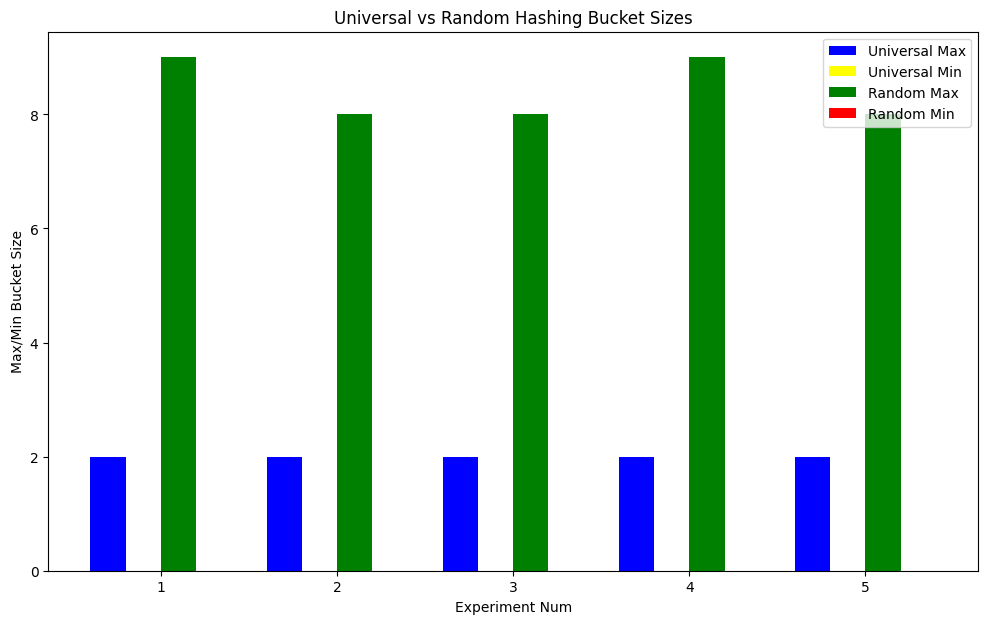

Random Hashing has more difference between the maximum and minimum chain


In [60]:
# Q1 c)
m = 500000
uni = Hash_Table(m)
ran = Hash_Table(m, hashing = "random")

results = {"Universal Hashing": [], "Random Hashing": []}

for i in range(5):
    for j in range(1, m+1):
        uni.universal_hash_function(j)
        ran.random_hash_function(j)
    results["Universal Hashing"].append({'Max' : 0, 'Min' : m})
    for j in uni.A:
        if (len(j) > results["Universal Hashing"][-1]['Max']):
            results["Universal Hashing"][-1]['Max'] = len(j)
        if (len(j) < results["Universal Hashing"][-1]['Min']):
            results["Universal Hashing"][-1]['Min'] = len(j)
            
    results["Random Hashing"].append({'Max' : 0, 'Min' : m})
    for key in ran.hash_dict.keys():
        l = len(ran.hash_dict[key])
        if (l > results["Random Hashing"][-1]['Max']):
            results["Random Hashing"][-1]['Max'] = l
        if (l < results["Random Hashing"][-1]['Min']):
            results["Random Hashing"][-1]['Min'] = l
    
    uni = Hash_Table(m)
    ran = Hash_Table(m, hashing = "random")
    
for has in results.keys():
    print(f"{has} :")
    for i in range(5):
        print(f"        Max : {results[has][i]['Max']} {' '*(10-len(str(results[has][i]['Max'])))} Min : {results[has][i]['Min']}")
        
uma = [result['Max'] for result in results["Universal Hashing"]]
umi = [result['Min'] for result in results["Universal Hashing"]]
rma = [result['Max'] for result in results["Random Hashing"]]
rmi = [result['Min'] for result in results["Random Hashing"]]
plt.figure(figsize=(12, 7))
x = np.arange(1, 6)
plt.bar(x - 1.5 * 0.2, uma, width=0.2, label='Universal Max', color='blue')
plt.bar(x - 0.5 * 0.2, umi, width=0.2, label='Universal Min', color='yellow')
plt.bar(x + 0.5 * 0.2, rma, width=0.2, label='Random Max', color='green')
plt.bar(x + 1.5 * 0.2, rmi, width=0.2, label='Random Min', color='red')

plt.xlabel('Experiment Num')
plt.ylabel('Max/Min Bucket Size')
plt.title('Universal vs Random Hashing Bucket Sizes')
plt.xticks(x)
plt.legend()
plt.show()

if (max(uma) - min(umi) < max(rma) - min(rmi)):
    print("Random Hashing has more difference between the maximum and minimum chain")
else:
    print("Universal Hashing has more difference between the maximum and minimum chain")

In [66]:
def dec_to_bin(n):
    binar = ''
    while (n > 0):
        binar += str(str(n%2))
        n = n//2
    return binar

def Flajolet_Martin():
    words = []
    with open('words.txt', 'r') as f:
        words = f.readlines()

    has_vals = []

    for w in words:
        temp = w
        if (w[-1] == '\n'):
            temp = w[:-1]
        has_vals.extend([Hash_Table.hash_md5_string(temp)])
    
    for m in [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]:
        max_z = 0
        hash_table = Hash_Table(m)
        for i in has_vals:
            h_x = hash_table.universal_hash_function(i)
            bi = dec_to_bin(h_x)
            z = 0
            for k in bi:
                if (k == '0'):
                    z += 1
                else:
                    break
            max_z = max(max_z, z)
            
        est = 2**(max_z + 0.5)
        print(f"m : {m} {' '*(10-len(str(m)))} Max z : {max_z} {' '*(10-len(str(max_z)))} Distinct Words : {math.floor(est)}")
        
Flajolet_Martin()

m : 8           Max z : 2           Distinct Words : 5
m : 16          Max z : 3           Distinct Words : 11
m : 32          Max z : 4           Distinct Words : 22
m : 64          Max z : 5           Distinct Words : 45
m : 128         Max z : 6           Distinct Words : 90
m : 256         Max z : 7           Distinct Words : 181
m : 512         Max z : 8           Distinct Words : 362
m : 1024        Max z : 9           Distinct Words : 724
m : 2048        Max z : 10          Distinct Words : 1448
m : 4096        Max z : 11          Distinct Words : 2896
m : 8192        Max z : 10          Distinct Words : 1448


## Question 2
### Q2(a) Bloom Filter implementation


1. **False Positive Rate (FPR)**:
   - The probability that a non-present item is incorrectly identified as present.
   - Formula:
     $$ FPR \approx \left(1 - e^{-\frac{k \cdot n}{m}}\right)^k $$
     where:
     - \( m \): Size of the bit array.
     - \( k \): Number of hash functions.
     - \( n \): Number of items inserted (number of unique `StockCode` values).

2. **Optimal Number of Hash Functions**:
   - Minimizes FPR for given \( m \) and \( n \).
   - Formula:
     $$ k_{opt} = \frac{m}{n} \cdot \ln(2) \approx 0.693 \cdot \frac{m}{n} $$
     Example: For \( m = 10000 \), \( n \approx 4000 \), 
     $$ k_{opt} \approx 0.693 \cdot \frac{10000}{4000} = 0.693 \cdot 2.5 \approx 1.7325 $$
     Thus, \( k \approx 4 \) or \( k \approx 5 \) is optimal, though \( k = 7 \) is reasonable for practical purposes.

3. **Sensitivity**:
   - The probability that a present item is correctly identified (true positive rate).
   - Formula:
     $$ \text{Sensitivity} = 1 $$
     Since Bloom Filters have no false negatives, all present items are correctly identified.

4. **Experimental FPR Calculation**:
   - Empirical FPR is calculated as:
     $$ \text{FPR} = \frac{\text{Number of false positives}}{\text{Number of non-present items tested}} $$
     where false positives are non-present items incorrectly identified as present.

In [3]:
class BloomFilter:
    def __init__(self, size, hashfuncCnt):
        self.size = size            ## M : Size of bit array
        self.hashfuncCnt = hashfuncCnt ## K : Number of hash functions 
        self.bitArray = [0] * size

    def addElement(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            self.bitArray[hash] = 1

    def existCheck(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            if self.bitArray[hash] == 0:
                return False
        return True

    def hashFunction(self, element, seed):
        kHash = []
        for i in range(self.hashfuncCnt):
            hash = (hashlib.md5((str(element) + str(seed) + str(i)).encode()).hexdigest())
            kHash.append(int(hash, 16) % self.size)
        return kHash

In [7]:
retailDf = pd.read_csv('online-retail.csv')
uniqueStkCodes = retailDf['StockCode'].unique().tolist()
present_set = set(uniqueStkCodes)
n = len(uniqueStkCodes)



### Q2(b) Misra-Gries Algorithm

Frequency Estimation in a Data Stream

**Source:** `https://www.cs.dartmouth.edu/~ac/Teach/data-streams-lecnotes.pdf`

## Misra-Gries Algorithm Formulas

### 1. Stream and Frequency
- Let $S = \{ s_1, s_2, \dots, s_n \}$ be the stream of $n$ items (e.g., `StockCode` values).
- The **true frequency** of item $i$ is $f_i$:
  $$
  f_i = |\{ j : s_j = i \}|
  $$
  where $f_i$ is the number of times item $i$ appears in $S$.
- The **estimated frequency** from Misra-Gries is $\hat{f_i}$.


### 2. Misra-Gries Guarantee
- The algorithm guarantees to identify all items with frequency $f_i > \frac{n}{k}$.
- For each item $i$ in the output dictionary, the estimate $\hat{f_i}$ is bounded:
  $$
  f_i - \frac{n}{k} \leq \hat{f_i} \leq f_i
  $$
  where $\frac{n}{k}$ is the theoretical error bound on frequency estimates.




### 4. Maximum Frequency Error
- The **Maximum Error** in frequency estimates for items in the Misra-Gries output:
  $$
  \text{Max Error} = \max_{i \in \text{Misra-Gries items}} | f_i - \hat{f_i} |
  $$
- **Normalized max error** (for plotting):
  $$
  \frac{\text{Max Error}}{n}
  $$


### 5. Theoretical Error Bound
- The **theoretical upper bound** on frequency error:
  $$
  \text{Theoretical Bound} = \frac{n}{k}
  $$
- **Normalized theoretical bound**:
  $$
  \frac{\text{Theoretical Bound}}{n} = \frac{1}{k}
  $$



In [14]:
class DataStream:
    def __init__(self, thresh: int):
        if thresh <= 0:
            raise ValueError("Threshold must be positive")
        self.thresh = thresh
        self.freq_map = {}

    ## ACTUAL Misra-Gries Algorithm implementation
    def addElement(self, element):
        if element in self.freq_map.keys():
            self.freq_map[element] += 1
        else:
            self.freq_map[element] = 1
        if len(self.freq_map) >= self.thresh:
            keys_to_remove = []
            for key in self.freq_map.keys():
                self.freq_map[key] -= 1
                if self.freq_map[key] == 0:
                    keys_to_remove.append(key)
            for key in keys_to_remove:
                del self.freq_map[key]

    def queryEle(self, element):
        if element in self.freq_map.keys():
            return self.freq_map.get(element,0)
    
    def freqElereturn(self):
        return self.freq_map
        


In [13]:
dataframe = pd.read_csv('online-retail.csv')
stockCodes = dataframe['StockCode']
direct_freq_map = {}
for code in stockCodes:
    if code in direct_freq_map:
        direct_freq_map[code] += 1
    else:
        direct_freq_map[code] = 1

print("Direct frequency count of elements:")
print(len(direct_freq_map))
n = len(stockCodes)
print(f"Total items in stream: {n}")
print(f"Unique StockCodes: {len(direct_freq_map)}")


Direct frequency count of elements:
4070
Total items in stream: 541909
Unique StockCodes: 4070


# Question 3

In [68]:
def ToInt(data):
    count = 0
    new_dataset = pd.DataFrame()
    for i in data:
        if type(data[i][0]) == int or type(data[i][0]) == float:
            new_dataset[count] = data[i]
            count += 1
            continue
    return new_dataset

def Normalise(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal


def Losses(D, Y, C):
    prediction = D @ C.T
    loss = np.sum((prediction - Y) ** 2)
    return loss


def cost(D, C):
    cost = 0
    for i in range(D.shape[0]):
        dist = np.linalg.norm(D[i] - C, axis=1)
        cost += min(dist)**2
    return cost

In [75]:
dataset = fetch_kddcup99(subset=None)
N_orig = dataset.data.shape[0]
D_orig = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
# print(df_normal)

DATA = df_normal.to_numpy().astype(float) 
N = DATA.shape[0]
D = DATA.shape[1]
print(f"Original Data : Num Samples = {N_orig}, Num Features = {D_orig}")
print(f"Processed Data : Num Samples = {N}, Num Features = {D}")   # 3 features removed due to non-numeric values

Original Data : Num Samples = 494021, Num Features = 41
Processed Data : Num Samples = 494021, Num Features = 38


In [81]:
costs = []

for X in [5, 10, 15, 20, 25]:
    costs.extend([[]])
    for i in tqdm(range(5)):
        probabs = np.random.rand(D, X)
        M = np.zeros((D, X))
        M[probabs < 1/6] = np.sqrt(3/X)
        M[probabs > 5/6] = -np.sqrt(3/X)
        
        E = DATA @ M
        
        kE = KMeans(n_clusters=15)
        kE.fit(E)
        A = kE.cluster_centers_
        
        kDATA = KMeans(n_clusters=15)
        kDATA.fit(DATA)
        B = kDATA.cluster_centers_
        
        CostA = cost(DATA, A @ np.linalg.pinv(M))
        CostB = cost(DATA, B)
        costs[-1].append((CostA, CostB))
        
for i in range(len(costs)):
    print(f'X = {(i+1)*5}')
    for j in range(5):
        print(f'Loss(A) : {costs[i][j][0]}, Loss(B) : {costs[i][j][1]}')
    print()

100%|██████████| 5/5 [01:05<00:00, 13.08s/it]

X = 5
Loss(A) : 4.1072033128896525e+17, Loss(B) : 3475619987317.6685
Loss(A) : 3.828493357348655e+17, Loss(B) : 3229015236599.067
Loss(A) : 4.1165498015396026e+17, Loss(B) : 3244815232368.057
Loss(A) : 4.499575998912104e+17, Loss(B) : 3700742048277.095
Loss(A) : 4.111588883474565e+17, Loss(B) : 4113403300527.0464

X = 10
Loss(A) : 3.844567953508702e+17, Loss(B) : 3546184835081.6123
Loss(A) : 3.5480571018433286e+17, Loss(B) : 3242875982100.5405
Loss(A) : 3.834972054104725e+17, Loss(B) : 3753081458251.6436
Loss(A) : 4.3939711694409926e+17, Loss(B) : 3230590323433.338
Loss(A) : 3.464830771240934e+17, Loss(B) : 3227484044851.971

X = 15
Loss(A) : 1.8656612508274608e+17, Loss(B) : 3357362426377.6
Loss(A) : 2.3193362554519856e+17, Loss(B) : 3231486816161.5557
Loss(A) : 3.674323254564348e+17, Loss(B) : 3288150745776.0156
Loss(A) : 3.5187834263865184e+17, Loss(B) : 4000611544743.026
Loss(A) : 3.974795325179768e+17, Loss(B) : 3527333212875.983

X = 20
Loss(A) : 1.9303934164757226e+17, Loss(B) :

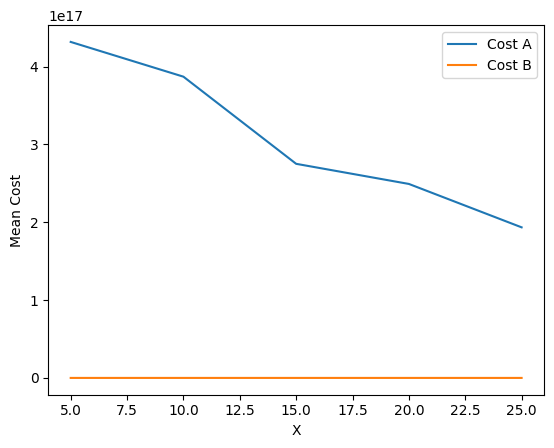

In [80]:
mean_costs_A = [np.mean([i[0] for i in cc]) for cc in costs]
mean_costs_B = [np.mean([i[1] for i in cc]) for cc in costs]
plt.plot([5, 10, 15, 20, 25], mean_costs_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], mean_costs_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()

In [21]:
Y = dataset.target
YLABEL = Normalise(pd.DataFrame(Y)).to_numpy()
# print((pd.DataFrame(YLABEL))[0].unique())

C:\Users\jonsn\AppData\Local\Temp\ipykernel_30544\560361736.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


In [ ]:
loss = []

for X in [25, 50, 100, 200, 500]:
    loss.extend([[]])
    for j in tqdm(range(5)):
        probabs = np.random.rand(X, N)
        M = np.zeros((X, N))
        M[probabs < 1/6] = np.sqrt(3/X)
        M[probabs > 5/6] = -np.sqrt(3/X)
        MSPA = csc_matrix(M)
        
        E = MSPA @ DATA
        Z = MSPA @ YLABEL
        
        # print('le')
        lE = LinearRegression()
        lE.fit(E, Z)
        A = lE.coef_
    
        lDATA = LinearRegression()
        lDATA.fit(DATA, YLABEL)
        B = lDATA.coef_
        # print('done')
        LossA = Losses(DATA, YLABEL, A)
        LossB = Losses(DATA, YLABEL, B)
        loss[-1].append((LossA, LossB))
    
for i in range(len(loss)):
    print(f'X = {(i+1)*5}')
    for j in range(5):
        print(f'Loss(A) : {loss[i][j][0]}, Loss(B) : {loss[i][j][1]}')
    print()

100%|██████████| 5/5 [01:32<00:00, 18.51s/it]

X = 5
Loss(A) : 8689201.528672678, Loss(B) : 28736845.96419724
Loss(A) : 5544597.904423503, Loss(B) : 28736845.96419724
Loss(A) : 3052450.4373760666, Loss(B) : 28736845.96419724
Loss(A) : 8751863.069873601, Loss(B) : 28736845.96419724
Loss(A) : 3378568.8945591543, Loss(B) : 28736845.96419724

X = 10
Loss(A) : 1384450.5238042525, Loss(B) : 28736845.96419724
Loss(A) : 2011888.9046137985, Loss(B) : 28736845.96419724
Loss(A) : 1706442.821087033, Loss(B) : 28736845.96419724
Loss(A) : 2252156.5567872496, Loss(B) : 28736845.96419724
Loss(A) : 1055744.4586237485, Loss(B) : 28736845.96419724

X = 15
Loss(A) : 795419.7315426926, Loss(B) : 28736845.96419724
Loss(A) : 958313.7526626051, Loss(B) : 28736845.96419724
Loss(A) : 799001.5804667263, Loss(B) : 28736845.96419724
Loss(A) : 928806.7340054985, Loss(B) : 28736845.96419724
Loss(A) : 845292.9384201884, Loss(B) : 28736845.96419724

X = 20
Loss(A) : 625797.8232126699, Loss(B) : 28736845.96419724
Loss(A) : 618079.9134456122, Loss(B) : 28736845.9641

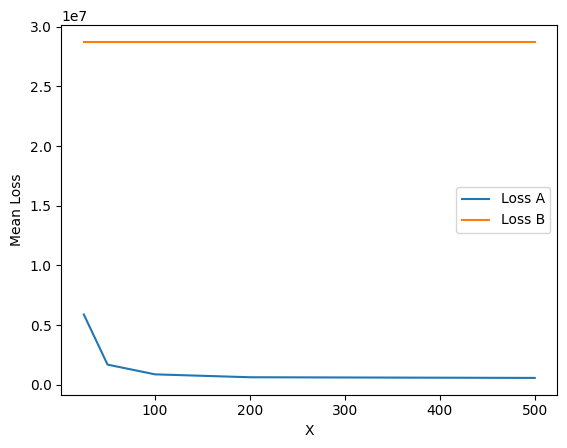

In [43]:
m_loss_A = [np.mean([i[0] for i in ll]) for ll in loss]
m_loss_B = [np.mean([i[1] for i in ll]) for ll in loss]
plt.plot([25, 50, 100, 200, 500], m_loss_A, label='Loss A')
plt.plot([25, 50, 100, 200, 500], m_loss_B, label='Loss B')
plt.xlabel('X')
plt.ylabel('Mean Loss')
plt.legend()
plt.show()